# Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn

# Variables

In [21]:
# define constants
mu = 3              # mean of log
sigma = 1           # std dev of log
C = 9.9e-11         # material const.
m = 2.7             # sensitivity to stress
n = 1.5             # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))

# define variables
n_defects = 1000    # size of random dataset

defect_size = torch.linspace(start=20,
                             end=600,
                             steps=n_defects)     # surface area of defect, A
stress_amp = torch.linspace(start=50,
                            end=500,
                            steps=n_defects)      # stress amplitude

# Data

In [22]:
# define fxn to generate the defect sizes based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # size of random samples generated

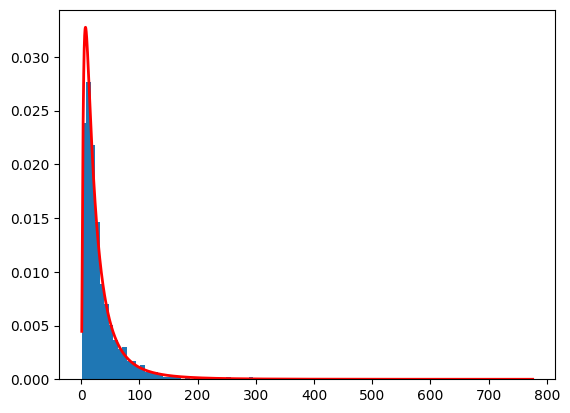

In [23]:
# show histogram and probability density fxn of randomly generated samples
count, bins, ignored = plt.hist(generate_defects(n_defects, mu, sigma),
                                100,
                                density=True,
                                align='mid')

x = np.linspace(min(bins), max(bins), 10000)
pdf = (np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
       /(x*sigma*np.sqrt(2*np.pi)))

plt.plot(x, pdf, linewidth=2, color='r')
plt.axis('tight')
plt.show()

# Shiozawa

In [24]:
# define fxn to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## S-N Curve

In [25]:
# data
N = fatigue_life(stress_amp, defect_size, C, m, n)    # N, no. of cycles, or fatigue life
S = stress_amp                                        # S, stress

# convert tensors to numpy arrays for plotting
N_plot = N.detach().numpy()
S_plot = S.detach().numpy()

print(N)
print(S)

print(N_plot)

tensor([2.8633e-17, 2.6774e-17, 2.5071e-17, 2.3507e-17, 2.2070e-17, 2.0745e-17,
        1.9523e-17, 1.8393e-17, 1.7347e-17, 1.6377e-17, 1.5477e-17, 1.4640e-17,
        1.3861e-17, 1.3135e-17, 1.2457e-17, 1.1824e-17, 1.1232e-17, 1.0678e-17,
        1.0158e-17, 9.6705e-18, 9.2127e-18, 8.7824e-18, 8.3776e-18, 7.9964e-18,
        7.6372e-18, 7.2984e-18, 6.9787e-18, 6.6766e-18, 6.3911e-18, 6.1210e-18,
        5.8652e-18, 5.6230e-18, 5.3934e-18, 5.1756e-18, 4.9689e-18, 4.7725e-18,
        4.5860e-18, 4.4086e-18, 4.2398e-18, 4.0792e-18, 3.9262e-18, 3.7804e-18,
        3.6415e-18, 3.5089e-18, 3.3824e-18, 3.2616e-18, 3.1462e-18, 3.0360e-18,
        2.9306e-18, 2.8297e-18, 2.7332e-18, 2.6409e-18, 2.5524e-18, 2.4677e-18,
        2.3865e-18, 2.3086e-18, 2.2339e-18, 2.1622e-18, 2.0934e-18, 2.0273e-18,
        1.9639e-18, 1.9029e-18, 1.8443e-18, 1.7879e-18, 1.7337e-18, 1.6816e-18,
        1.6314e-18, 1.5830e-18, 1.5365e-18, 1.4917e-18, 1.4485e-18, 1.4068e-18,
        1.3667e-18, 1.3280e-18, 1.2906e-

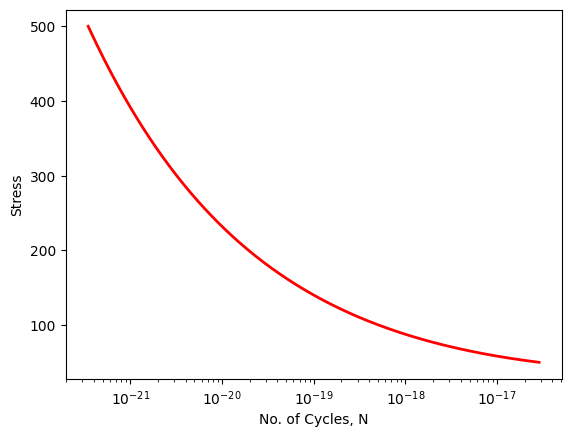

In [26]:
# create an S-N curve
plt.plot(N_plot, S,
         color='red',
         linewidth=2,
         markersize=12,
         )

# axis labels
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.xscale('log')

plt.show()

# Critical Defects

In [ ]:
# define fxn to select the crtical defect
# max defect = the one that dominates fatigue failure
def critical_defect(defects):
    return np.max(defects)

# Prediction

In [ ]:
# generate n_defects random defects
defects = generate_defects(n_defects, stress_amp, sigma)

# calculate the critical defect size
A_crit = critical_defect(defects)

# calculate fatigue life, N
N = fatigue_life(stress_amp, A_crit, C, m, n)